# AMAZON SENTIMENT ANALYSIS

In [77]:
# importing libraries
!pip install nltk

import pickle

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import re
from nltk.stem.porter import PorterStemmer
from sklearn.preprocessing import MinMaxScaler 
!pip install textblob
from textblob import TextBlob

!pip install tqdm
from tqdm import tqdm

from sklearn.feature_extraction.text import CountVectorizer

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression

from sklearn .svm import LinearSVC, SVC
from sklearn .naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack

import string


from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer


import string
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[nltk_data] Downloading package punkt to /Users/maryann/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maryann/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maryann/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## DATA EXTRACTION

In [78]:
# loading data set

df = pd.read_csv(r"/Users/maryann/Documents/TeamAlphadataset.csv")


In [79]:
df.head()


,productId,Rating,Date,Feedback_translated,Feedback,Unnamed: 5,Name,Country,Upvotes,Downvotes,...,Ease of use,Power efficiency,Fit,Packaging,Brightness,Application scope,Compatibility,Ease of use,Hygiene,Item specification accuracy
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,très bon emballage bien protégé mais pas encor...,NaN,a***r,FR,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...","lights are extremely bright, we used 1.2v batt...",NaN,Amazon Shopper,US,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,Me gusto mucho para mi hijo. Es tal cual la de...,NaN,R***S,CL,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...","corresponds to the description, fast delivery,...",NaN,Amazon Shopper,UA,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,As described. Good quality. Batteries not incl...,NaN,J***h,HU,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# EDA
#### DESCRIPTIVE ANALYSIS

In [80]:
df.describe()


,productId,Rating,Unnamed: 5,Upvotes,Downvotes
count,2.192000e+03,2192.000000,0.0,2192.000000,2192.0
mean,7.947122e+14,94.917883,NaN,0.000456,0.0
std,4.132998e+14,15.858014,NaN,0.021359,0.0
min,3.280172e+10,20.000000,NaN,0.000000,0.0
25%,1.010000e+15,100.000000,NaN,0.000000,0.0
50%,1.010000e+15,100.000000,NaN,0.000000,0.0
75%,1.010000e+15,100.000000,NaN,0.000000,0.0
max,1.010000e+15,100.000000,NaN,1.000000,0.0


In [81]:
df.head()

,productId,Rating,Date,Feedback_translated,Feedback,Unnamed: 5,Name,Country,Upvotes,Downvotes,...,Ease of use,Power efficiency,Fit,Packaging,Brightness,Application scope,Compatibility,Ease of use,Hygiene,Item specification accuracy
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,très bon emballage bien protégé mais pas encor...,NaN,a***r,FR,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...","lights are extremely bright, we used 1.2v batt...",NaN,Amazon Shopper,US,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,Me gusto mucho para mi hijo. Es tal cual la de...,NaN,R***S,CL,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...","corresponds to the description, fast delivery,...",NaN,Amazon Shopper,UA,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,As described. Good quality. Batteries not incl...,NaN,J***h,HU,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   productId                    2192 non-null   float64
 1   Rating                       2192 non-null   int64  
 2   Date                         2192 non-null   object 
 3   Feedback_translated          1306 non-null   object 
 4   Feedback                     1306 non-null   object 
 5   Unnamed: 5                   0 non-null      float64
 6   Name                         2192 non-null   object 
 7   Country                      2190 non-null   object 
 8   Upvotes                      2192 non-null   int64  
 9   Downvotes                    2192 non-null   int64  
 10  Product Longevity            41 non-null     object 
 11  User Instructions Clarity    44 non-null     object 
 12  Pain Level                   36 non-null     object 
 13  Design            

In [83]:
print(df.isnull().sum())


productId                         0
Rating                            0
Date                              0
Feedback_translated             886
Feedback                        886
Unnamed: 5                     2192
Name                              0
Country                           2
Upvotes                           0
Downvotes                         0
Product Longevity              2151
User Instructions Clarity      2148
Pain Level                     2156
Design                         2161
Quality                        2165
Ease of Installation           2142
Quality of Material            2145
Functionality                  2151
User Friendly                  2176
Quality of Material            2179
Adaptability To Environment    2187
Versatility                    2187
Size Options                   2174
Quality of Shine               2177
Usability                      2191
Gameplay Experience            2191
Style                          2177
Color Options               

In [84]:
df.columns


Index(['productId', 'Rating', 'Date', 'Feedback_translated', 'Feedback',
       'Unnamed: 5', 'Name', 'Country', 'Upvotes', 'Downvotes',
       'Product Longevity', 'User Instructions Clarity', 'Pain Level',
       'Design', 'Quality', 'Ease of Installation', 'Quality of Material',
       'Functionality', 'User Friendly', 'Quality of Material',
       'Adaptability To Environment', 'Versatility', 'Size Options',
       'Quality of Shine', 'Usability', 'Gameplay Experience', 'Style',
       'Color Options', 'Value for money', 'Tech support', 'Ease of use',
       'Power efficiency', 'Fit', 'Packaging ', 'Brightness',
       'Application scope', 'Compatibility', 'Ease of use', 'Hygiene',
       'Item specification accuracy'],
      dtype='object')

In [85]:
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)


productId                        0.000000
Rating                           0.000000
Date                             0.000000
Feedback_translated             40.419708
Feedback                        40.419708
Unnamed: 5                     100.000000
Name                             0.000000
Country                          0.091241
Upvotes                          0.000000
Downvotes                        0.000000
Product Longevity               98.129562
User Instructions Clarity       97.992701
Pain Level                      98.357664
Design                          98.585766
Quality                         98.768248
Ease of Installation            97.718978
Quality of Material             97.855839
Functionality                   98.129562
User Friendly                   99.270073
Quality of Material             99.406934
Adaptability To Environment     99.771898
Versatility                     99.771898
Size Options                    99.178832
Quality of Shine                99

In [86]:
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

# Define the threshold for dropping columns (e.g., 50% missing values)
threshold = 50

# Identify columns that exceed the threshold
columns_to_drop = missing_percentage[missing_percentage > threshold].index

# Drop these columns from the DataFrame
df.drop(columns=columns_to_drop, inplace=True)

# Check the cleaned DataFrame
print(df)


productId                        0.000000
Rating                           0.000000
Date                             0.000000
Feedback_translated             40.419708
Feedback                        40.419708
Unnamed: 5                     100.000000
Name                             0.000000
Country                          0.091241
Upvotes                          0.000000
Downvotes                        0.000000
Product Longevity               98.129562
User Instructions Clarity       97.992701
Pain Level                      98.357664
Design                          98.585766
Quality                         98.768248
Ease of Installation            97.718978
Quality of Material             97.855839
Functionality                   98.129562
User Friendly                   99.270073
Quality of Material             99.406934
Adaptability To Environment     99.771898
Versatility                     99.771898
Size Options                    99.178832
Quality of Shine                99

In [87]:
df.head(10)



,productId,Rating,Date,Feedback_translated,Feedback,Name,Country,Upvotes,Downvotes
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,très bon emballage bien protégé mais pas encor...,a***r,FR,0,0
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...","lights are extremely bright, we used 1.2v batt...",Amazon Shopper,US,0,0
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,Me gusto mucho para mi hijo. Es tal cual la de...,R***S,CL,0,0
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...","corresponds to the description, fast delivery,...",Amazon Shopper,UA,0,0
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,As described. Good quality. Batteries not incl...,J***h,HU,0,0
5,1.010000e+15,100,14-May-24,Works very well and is of good quality,Funciona muy bien y es de buena calidad,D***v,MX,0,0
6,1.010000e+15,100,23-May-24,Excellent quality.,Excellent quality.,Amazon Shopper,HU,0,0
7,1.010000e+15,100,24-May-24,Great!! Fast!!,מעולה!! מהיר!!,R***n,IL,0,0
8,1.010000e+15,100,17-May-24,"Excellent, my baby loves it, I recommend it to...","Excelente, a mi bebé le encanta, lo recomiendo...",J***a,ES,0,0
9,1.010000e+15,100,13-May-24,kid likes it a lot. I like it even more becaus...,kid likes it a lot. I like it even more becaus...,S***g,AE,0,0


In [88]:
df.describe(include = ["object"])


,Date,Feedback_translated,Feedback,Name,Country
count,2192,1306,1306,2192,2190
unique,181,1211,1224,629,102
top,16-May-24,They where cute like the pic just not as shiny,They where cute like the pic just not as shiny,Amazon Shopper,US
freq,37,11,11,473,462


In [89]:
# drop 'feedback' column
df=df.drop('Feedback', axis=1)


In [90]:
df.tail(15)


,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes
2177,4.000000e+12,100,14-Apr-24,NaN,S***a,BY,0,0
2178,4.000000e+12,100,19-Dec-23,NaN,S***H,CA,0,0
2179,4.000000e+12,100,07-May-24,NaN,Amazon Shopper,UK,0,0
2180,4.000000e+12,100,02-Apr-24,NaN,y***l,FR,0,0
2181,4.000000e+12,100,04-Apr-24,NaN,s***s,UA,0,0
2182,4.000000e+12,100,29-Apr-24,NaN,Amazon Shopper,RO,0,0
2183,1.010000e+15,100,10-Mar-24,I recommend all the old man to the seller.,S***r,UA,0,0
2184,1.010000e+15,100,05-Dec-23,"Put it, it works.",D***v,KZ,0,0
2185,1.010000e+15,100,23-Feb-24,NaN,A***v,RU,0,0
2186,1.010000e+15,100,21-May-24,NaN,Amazon Shopper,EE,0,0


In [91]:
#fill missing values in feedback transalted with dummy variable (not available)
df['Feedback_translated']=df['Feedback_translated'].fillna('No review')
print(df)


         productId  Rating       Date  \
0     1.010000e+15     100  18-May-24   
1     1.010000e+15      60  29-May-24   
2     1.010000e+15     100  25-May-24   
3     1.010000e+15     100  23-Apr-24   
4     1.010000e+15     100  03-May-24   
...            ...     ...        ...   
2187  1.010000e+15     100  09-May-24   
2188  1.010000e+15     100  27-Apr-24   
2189  1.010000e+15     100  13-May-24   
2190  1.010000e+15     100  12-Feb-24   
2191  1.010000e+15     100  20-May-24   

                                    Feedback_translated            Name  \
0     Very good packaging well protected but not yet...           a***r   
1     lights are extremely bright, we used 1.2v batt...  Amazon Shopper   
2     I like it very much for my son. It is as the d...           R***S   
3     corresponds to the description, fast delivery,...  Amazon Shopper   
4     As described. Good quality. Batteries not incl...           J***h   
...                                                 ...  

In [92]:
#df.dropna(subset=['Feedback_translated'], inplace=True)
#print(df)

In [93]:
df.tail(15)

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes
2177,4.000000e+12,100,14-Apr-24,No review,S***a,BY,0,0
2178,4.000000e+12,100,19-Dec-23,No review,S***H,CA,0,0
2179,4.000000e+12,100,07-May-24,No review,Amazon Shopper,UK,0,0
2180,4.000000e+12,100,02-Apr-24,No review,y***l,FR,0,0
2181,4.000000e+12,100,04-Apr-24,No review,s***s,UA,0,0
2182,4.000000e+12,100,29-Apr-24,No review,Amazon Shopper,RO,0,0
2183,1.010000e+15,100,10-Mar-24,I recommend all the old man to the seller.,S***r,UA,0,0
2184,1.010000e+15,100,05-Dec-23,"Put it, it works.",D***v,KZ,0,0
2185,1.010000e+15,100,23-Feb-24,No review,A***v,RU,0,0
2186,1.010000e+15,100,21-May-24,No review,Amazon Shopper,EE,0,0


In [94]:
df.describe(include = ["object"])


,Date,Feedback_translated,Name,Country
count,2192,2192,2192,2190
unique,181,1212,629,102
top,16-May-24,No review,Amazon Shopper,US
freq,37,886,473,462


In [95]:
# convert date to date time and extract month and year
df['date_column'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 2: Check for rows where the conversion failed (NaT will be there)
invalid_rows = df[df['date_column'].isna()]
print("Rows with invalid dates:\n", invalid_rows)

# Now you can use the .dt accessor safely on properly converted datetime column
df['year'] = df['date_column'].dt.year  # Extract year
df['month'] = df['date_column'].dt.month  # Extract month
df['month_name'] = df['date_column'].dt.strftime('%B')
print(df)

Rows with invalid dates:
 Empty DataFrame
Columns: [productId, Rating, Date, Feedback_translated, Name, Country, Upvotes, Downvotes, date_column]
Index: []
         productId  Rating       Date  \
0     1.010000e+15     100  18-May-24   
1     1.010000e+15      60  29-May-24   
2     1.010000e+15     100  25-May-24   
3     1.010000e+15     100  23-Apr-24   
4     1.010000e+15     100  03-May-24   
...            ...     ...        ...   
2187  1.010000e+15     100  09-May-24   
2188  1.010000e+15     100  27-Apr-24   
2189  1.010000e+15     100  13-May-24   
2190  1.010000e+15     100  12-Feb-24   
2191  1.010000e+15     100  20-May-24   

                                    Feedback_translated            Name  \
0     Very good packaging well protected but not yet...           a***r   
1     lights are extremely bright, we used 1.2v batt...  Amazon Shopper   
2     I like it very much for my son. It is as the d...           R***S   
3     corresponds to the description, fast delivery

In [96]:
df.head()

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,a***r,FR,0,0,2024-05-18,2024,5,May
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...",Amazon Shopper,US,0,0,2024-05-29,2024,5,May
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,R***S,CL,0,0,2024-05-25,2024,5,May
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...",Amazon Shopper,UA,0,0,2024-04-23,2024,4,April
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,J***h,HU,0,0,2024-05-03,2024,5,May


In [97]:
print(df.isnull().sum())

productId              0
Rating                 0
Date                   0
Feedback_translated    0
Name                   0
Country                2
Upvotes                0
Downvotes              0
date_column            0
year                   0
month                  0
month_name             0
dtype: int64


In [98]:
df.columns


Index(['productId', 'Rating', 'Date', 'Feedback_translated', 'Name', 'Country',
       'Upvotes', 'Downvotes', 'date_column', 'year', 'month', 'month_name'],
      dtype='object')

#### UNIVARIATE ANALYSIS

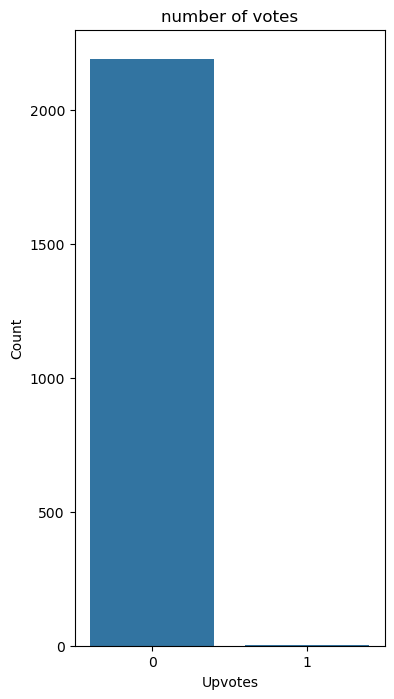

In [99]:

# create new column for votes where upvote = 1, downvote = 0

def votes (Upvotes):
    if Upvotes >= 1:
        return 1
    
    else:
        return 0
    
    
df['votes']=df['Upvotes'].apply(votes)

plt.figure(figsize= (4,8))
sns.countplot(x='Upvotes', data = df)
plt.xlabel ('Upvotes')
plt.ylabel ('Count')
plt.title('number of votes');


In [100]:
count_upvotes=df['Upvotes'].value_counts()
print(count_upvotes)

Upvotes
0    2191
1       1
Name: count, dtype: int64


Rating
100    1925
80      115
60       67
20       53
40       32
Name: count, dtype: int64


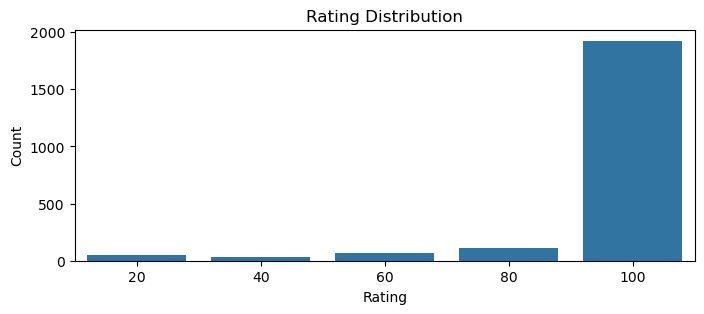

In [101]:
count_rating =df['Rating'].value_counts()
print(count_rating)

plt.figure(figsize= (8,3))
sns.countplot(x='Rating', data = df)
plt.xlabel ('Rating')
plt.ylabel ('Count')
plt.title('Rating Distribution');

0       0
1       0
2       0
3       0
4       0
       ..
2187    0
2188    0
2189    0
2190    0
2191    0
Name: is_no_review, Length: 2192, dtype: int64


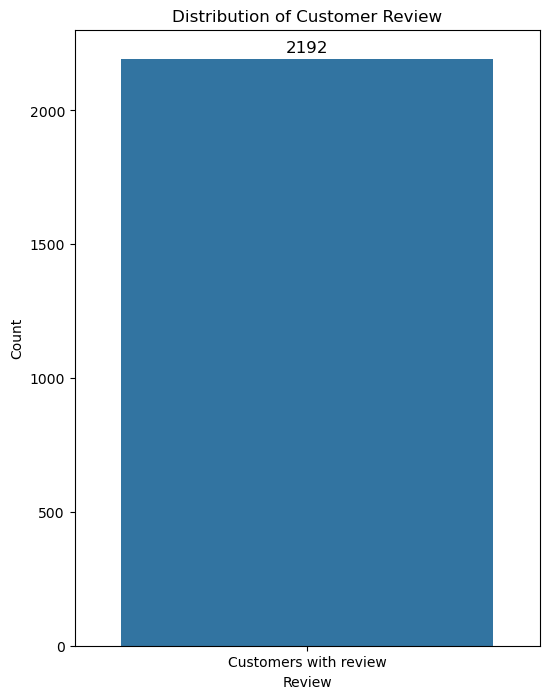

In [102]:
# creating column for no review columns

df['is_no_review'] = df['Feedback_translated'].apply(lambda x: 1 if x == 'no review' else 0)

print(df['is_no_review'])

df['is_no_review'] = df['is_no_review'].replace({1: 'Customers without review', 0: 'Customers with review'})

plt.figure(figsize=(6, 8))

# Create the bar chart
ax = sns.countplot(x='is_no_review', data=df)

# Add labels to each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Set labels and title
plt.xlabel('Review')
plt.ylabel('Count')
plt.title('Distribution of Customer Review')

# Show the plot
plt.show()


In [103]:
# Create a dictionary mapping country codes to full names
Country_mapping = {
    'FR': 'France',
    'US': 'United States',
    'CL': 'Chile',
    'UA': 'Ukraine',
    'HU': 'Hungary',
    'MX': 'Mexico',
    'IL': 'Israel',
    'ES': 'Spain',
    'AE': 'United Arab Emirates',
    'AU': 'Australia',
    'CH': 'Switzerland',
    'PL': 'Poland',
    'CA': 'Canada',
    'NL': 'Netherlands',
    'UK': 'United Kingdom',
    'BR': 'Brazil',
    'DE': 'Germany',
    'OM': 'Oman',
    'IT': 'Italy',
    'CZ': 'Czech Republic',
    'HR': 'Croatia',
    'BG': 'Bulgaria',
    'PE': 'Peru',
    'EU': 'European Union',
    'SA': 'Saudi Arabia',
    'KZ': 'Kazakhstan',
    'CO': 'Colombia',
    'ZA': 'South Africa',
    'UY': 'Uruguay',
    'GR': 'Greece',
    'RO': 'Romania',
    'DO': 'Dominican Republic',
    'LK': 'Sri Lanka',
    'BY': 'Belarus',
    'LT': 'Lithuania',
    'AR': 'Argentina',
    'KR': 'South Korea',
    'CY': 'Cyprus',
    'PK': 'Pakistan',
    'KW': 'Kuwait',
    'MU': 'Mauritius',
    'SK': 'Slovakia',
    'GT': 'Guatemala',
    'IE': 'Ireland',
    'PT': 'Portugal',
    'HK': 'Hong Kong',
    'RU': 'Russia',
    'AM': 'Armenia',
    'SE': 'Sweden',
    'NO': 'Norway',
    'KE': 'Kenya',
    'TR': 'Turkey',
    'SR': 'Suriname',
    'NZ': 'New Zealand',
    'GB': 'United Kingdom',
    'JP': 'Japan',
    'TC': 'Turks and Caicos Islands',
    'JM': 'Jamaica',
    'MY': 'Malaysia',
    'NG': 'Nigeria',
    'NA': 'Namibia',
    'PS': 'Palestine',
    'MA': 'Morocco',
    'BH': 'Bahrain',
    'RE': 'Réunion',
    'RS': 'Serbia',
    'EE': 'Estonia',
    'MT': 'Malta',
    'FX': 'Metropolitan France',
    'SG': 'Singapore',
    'SI': 'Slovenia',
    'FI': 'Finland',
    'SRB': 'Serbia',
    'LV': 'Latvia',
    'DZ': 'Algeria',
    'CR': 'Costa Rica',
    'QA': 'Qatar',
    'AL': 'Albania',
    'TN': 'Tunisia',
    'CI': 'Côte d\'Ivoire',
    'UZ': 'Uzbekistan',
    'BE': 'Belgium',
    'AO': 'Angola',
    'MK': 'North Macedonia',
    'BO': 'Bolivia',
    'MZ': 'Mozambique',
    'TT': 'Trinidad and Tobago',
    'GP': 'Guadeloupe',
    'FJ': 'Fiji',
    'GE': 'Georgia',
    'MV': 'Maldives',
    'GH': 'Ghana',
    'SV': 'El Salvador',
    'CV': 'Cape Verde',
    'MD': 'Moldova',
    'TH': 'Thailand',
    'AT': 'Austria',
    'TW': 'Taiwan',
    'SC': 'Seychelles',
    'AZ': 'Azerbaijan',
    'LU': 'Luxembourg',
    'EC': 'Ecuador',
    'IS': 'Iceland',
}
# Replace the country codes in the 'Country' column with full names
df['Country'] = df['Country'].map(Country_mapping).fillna(df['Country'])

df. head()

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name,votes,is_no_review
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,a***r,France,0,0,2024-05-18,2024,5,May,0,Customers with review
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...",Amazon Shopper,United States,0,0,2024-05-29,2024,5,May,0,Customers with review
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,R***S,Chile,0,0,2024-05-25,2024,5,May,0,Customers with review
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...",Amazon Shopper,Ukraine,0,0,2024-04-23,2024,4,April,0,Customers with review
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,J***h,Hungary,0,0,2024-05-03,2024,5,May,0,Customers with review


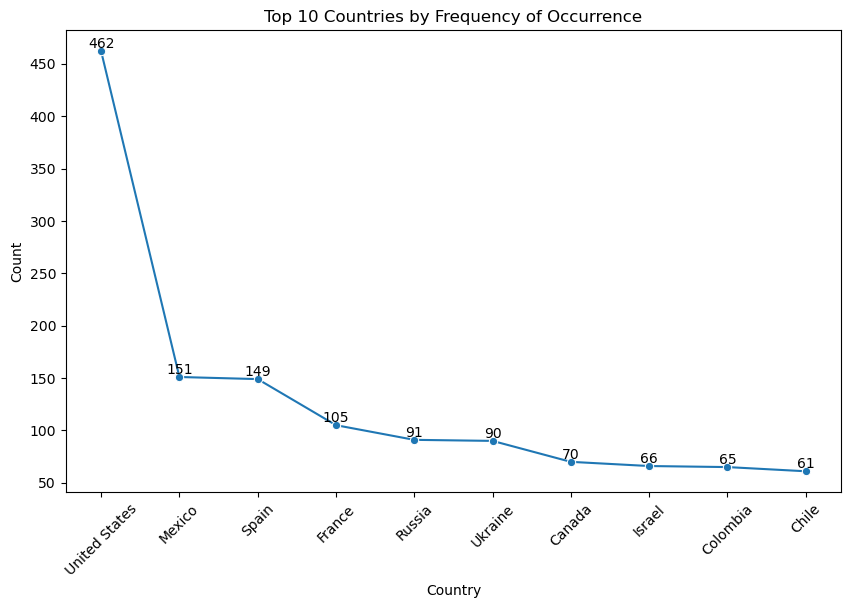

In [104]:
# Group the data by 'Country' to get the counts and select top 10
df_grouped = df['Country'].value_counts().reset_index().head(10)
df_grouped.columns = ['Country', 'Count']

# Set figure size
plt.figure(figsize=(10, 6))

# Create the line chart
ax = sns.lineplot(x='Country', y='Count', data=df_grouped, marker='o')

# Add labels to each point
for x, y in zip(df_grouped['Country'], df_grouped['Count']):
    ax.text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=10, color='black')

# Set labels and title
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries by Frequency of Occurrence')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

#### BIVARIATE ANALYSIS

Text(0.5, 1.0, 'No Review Customers with Rating Distribution')

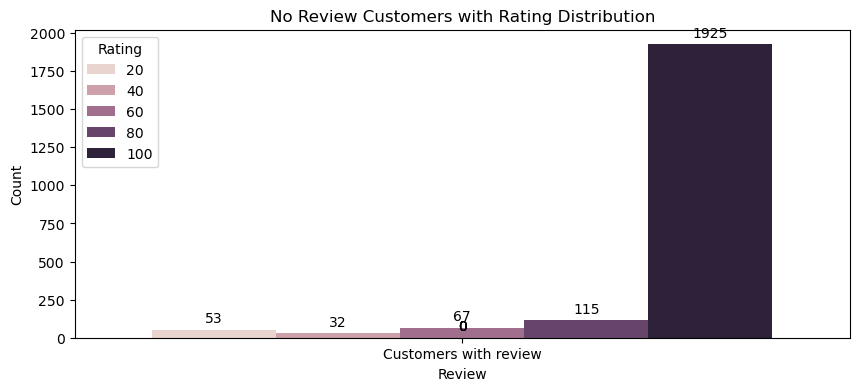

In [105]:
#investigating relationship between is_no review and rating


plt.figure(figsize=(10, 4))

# Create the bar chart
ax = sns.countplot(x='is_no_review', data=df, hue='Rating')

# Add labels to each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Set labels and title
plt.xlabel('Review')
plt.ylabel('Count')
plt.title('No Review Customers with Rating Distribution')



In [106]:
from textblob import TextBlob

# Function to calculate polarity with simple negation handling
def get_polarity(text):
    polarity = TextBlob(text).sentiment.polarity
    lower_text = text.lower()
    negations = ["not ", "never ", "no "]  # add more if needed
    for neg in negations:
        if neg in lower_text:
            polarity = -abs(polarity)  # flip polarity to negative
            break
    return polarity

# Function to categorize sentiment
def categorize_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    else:
        return 'Negative'

# Apply to DataFrame
df['polarity'] = df['Feedback_translated'].apply(get_polarity)
df['sentiment'] = df['polarity'].apply(categorize_sentiment)

# Display results
print(df[['Feedback_translated','polarity','sentiment']])

                                    Feedback_translated  polarity sentiment
0     Very good packaging well protected but not yet... -0.910000  Negative
1     lights are extremely bright, we used 1.2v batt... -0.337500  Negative
2     I like it very much for my son. It is as the d...  0.260000  Positive
3     corresponds to the description, fast delivery,...  0.200000  Positive
4     As described. Good quality. Batteries not incl... -0.450000  Negative
...                                                 ...       ...       ...
2187                                          Very good  0.910000  Positive
2188                                          No review -0.000000  Negative
2189  looks fine, not tried yet!....................... -0.520833  Negative
2190                                          No review -0.000000  Negative
2191                                          No review -0.000000  Negative

[2192 rows x 3 columns]


0       Positive
1       Positive
2       Positive
3       Positive
4       Positive
          ...   
2187    Positive
2188    Negative
2189    Positive
2190    Negative
2191    Negative
Name: Feedback_translated, Length: 2192, dtype: object


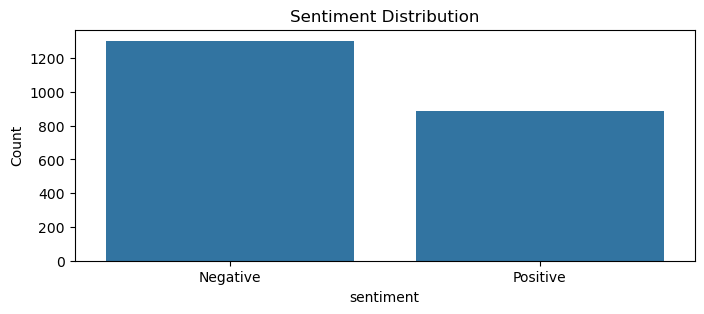

In [107]:
def get_sentiment(Feedback_translated):
    # Calculate the polarity score
    blob = TextBlob(Feedback_translated)
    polarity = blob.sentiment.polarity
    
    # Classify the sentiment
    if polarity > 0:
        return 'Positive'
    #elif polarity < 0:
        #return 'Negative'
    else:
        return 'Negative'
    
sentiment =df['Feedback_translated'].apply(get_sentiment)

#print(df['sentiment'])
print(sentiment)

plt.figure(figsize= (8,3))
sns.countplot(x='sentiment', data = df)
plt.xlabel ('sentiment')
plt.ylabel ('Count')
plt.title('Sentiment Distribution');

In [108]:
df.tail()

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name,votes,is_no_review,polarity,sentiment
2187,1.010000e+15,100,09-May-24,Very good,М***ч,Russia,0,0,2024-05-09,2024,5,May,0,Customers with review,0.910000,Positive
2188,1.010000e+15,100,27-Apr-24,No review,Amazon Shopper,Russia,0,0,2024-04-27,2024,4,April,0,Customers with review,-0.000000,Negative
2189,1.010000e+15,100,13-May-24,"looks fine, not tried yet!.......................",O***a,Romania,0,0,2024-05-13,2024,5,May,0,Customers with review,-0.520833,Negative
2190,1.010000e+15,100,12-Feb-24,No review,M***K,Albania,0,0,2024-02-12,2024,2,February,0,Customers with review,-0.000000,Negative
2191,1.010000e+15,100,20-May-24,No review,d***d,Ukraine,0,0,2024-05-20,2024,5,May,0,Customers with review,-0.000000,Negative


In [109]:
# replace missing value for country
df['Country'].fillna('Unknown', inplace=True)
df['Rating'].fillna('Unknown', inplace=True)

print(df.isnull().sum())

productId              0
Rating                 0
Date                   0
Feedback_translated    0
Name                   0
Country                0
Upvotes                0
Downvotes              0
date_column            0
year                   0
month                  0
month_name             0
votes                  0
is_no_review           0
polarity               0
sentiment              0
dtype: int64


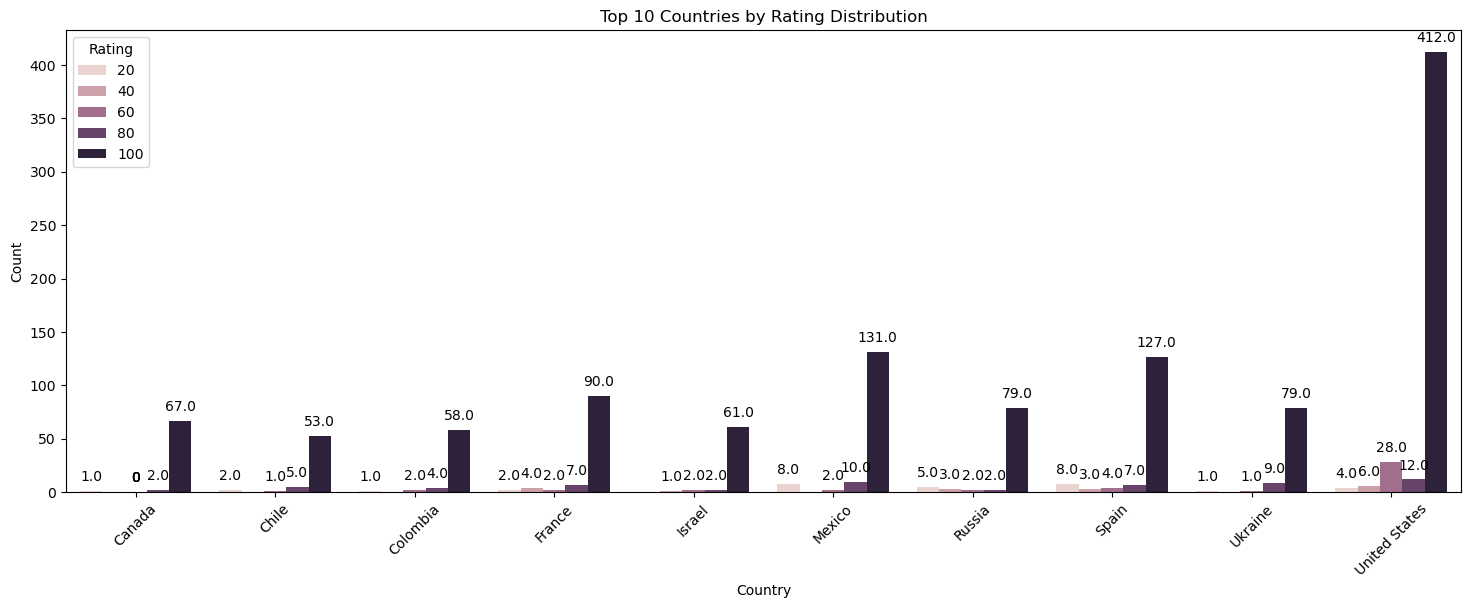

In [110]:
# Group the data by 'Country' and 'Rating' and select the top 10 countries
top_10_countries = df['Country'].value_counts().head(10).index
df_grouped = df[df['Country'].isin(top_10_countries)].groupby(['Country', 'Rating']).size().reset_index(name='Count')

# Handle NaN values in the 'Count' column
df_grouped['Count'] = df_grouped['Count'].fillna(0)

# Ensure 'Count' is of integer type
df_grouped['Count'] = df_grouped['Count'].astype(int)

# Set figure size
plt.figure(figsize=(18, 6))

# Create the bar chart
ax = sns.barplot(x='Country', y='Count', hue='Rating', data=df_grouped)

# Add labels to each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Set labels and title
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries by Rating Distribution')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

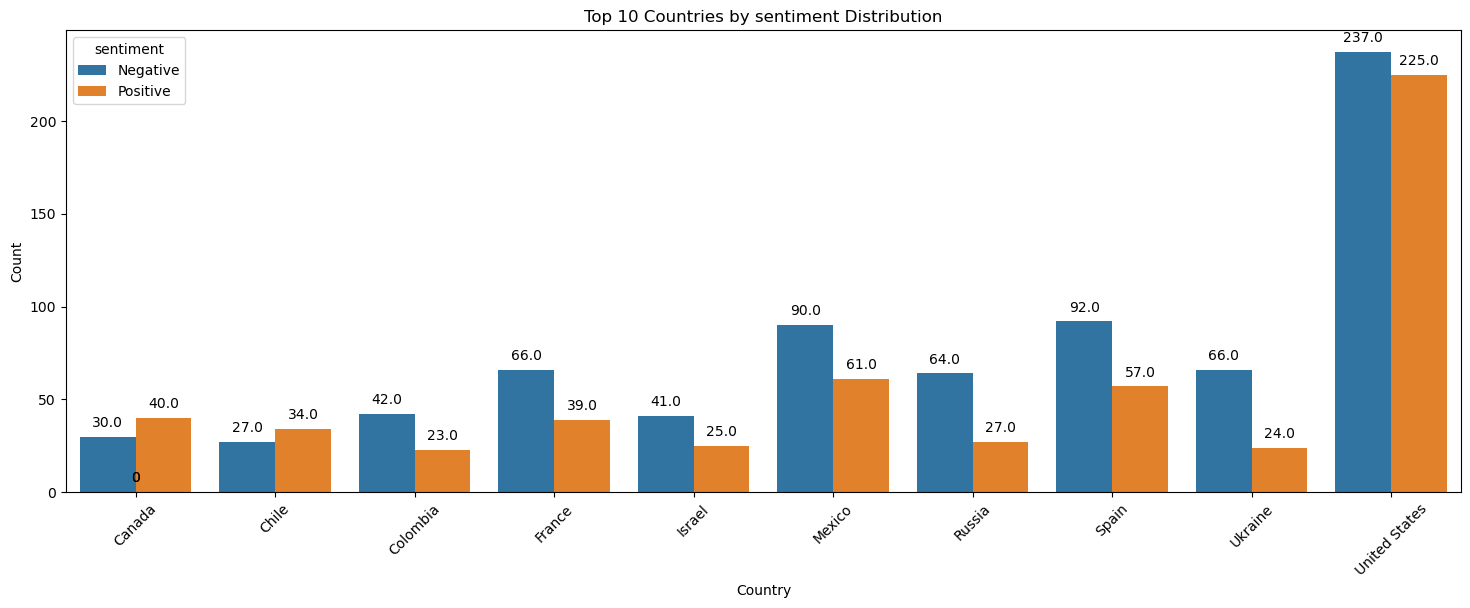

In [111]:
# Group the data by 'Country' and 'sentiment' and select the top 10 countries
top_10_countries = df['Country'].value_counts().head(10).index
df_grouped = df[df['Country'].isin(top_10_countries)].groupby(['Country', 'sentiment']).size().reset_index(name='Count')

# Handle NaN values in the 'Count' column
df_grouped['Count'] = df_grouped['Count'].fillna(0)

# Ensure 'Count' is of integer type
df_grouped['Count'] = df_grouped['Count'].astype(int)

# Set figure size
plt.figure(figsize=(18, 6))

# Create the bar chart
ax = sns.barplot(x='Country', y='Count', hue='sentiment', data=df_grouped)

# Add labels to each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Set labels and title
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries by sentiment Distribution')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

In [112]:
#scale rating using min max scaler
#scaler = MinMaxScaler()
#scaled_rating = scaler.fit_transform(df[['Rating']])
#print(df)

In [113]:
#data = df['Feedback_translated']
        
#df = pd.DataFrame(data)

#Vectorizer=CountVectorizer()
#scaled_text= Vectorizer.fit_transform(df['Feedback_translated'])

#X_dense = scaled_text.toarray()

# Step 2: Apply MinMaxScaler to scale the feature vectors
#X_scaled = scaler.fit_transform(X_dense)

# Create a DataFrame with scaled features
#df_scaled = pd.DataFrame(X_scaled, columns=Vectorizer.get_feature_names_out())

# Display the scaled DataFrame
#print(df_scaled)

#model = LinearRegression()
#model.fit(X_scaled, scaled_rating)

# Step 5: Predict the ratings using the model
#predicted_rating = model.predict(X_scaled)

# Calculate Mean Squared Error
#mse = mean_squared_error(scaled_rating, predicted_rating)
#print(f"Mean Squared Error: {mse}")

# Step 6: Plot the Linear Regression results
#plt.figure(figsize=(10, 6))
#plt.scatter(scaled_rating, predicted_rating, color='blue', label='Predicted vs Actual')
#plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ideal Fit')
#plt.xlabel('Scaled Ratings (Actual)')
#plt.ylabel('Scaled Ratings (Predicted)')
#plt.title('Linear Regression: Scaled Ratings vs Predicted Ratings')
#plt.legend()
#plt.grid(True)
#plt.show()

In [114]:
df.head()

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name,votes,is_no_review,polarity,sentiment
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,a***r,France,0,0,2024-05-18,2024,5,May,0,Customers with review,-0.9100,Negative
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...",Amazon Shopper,United States,0,0,2024-05-29,2024,5,May,0,Customers with review,-0.3375,Negative
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,R***S,Chile,0,0,2024-05-25,2024,5,May,0,Customers with review,0.2600,Positive
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...",Amazon Shopper,Ukraine,0,0,2024-04-23,2024,4,April,0,Customers with review,0.2000,Positive
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,J***h,Hungary,0,0,2024-05-03,2024,5,May,0,Customers with review,-0.4500,Negative


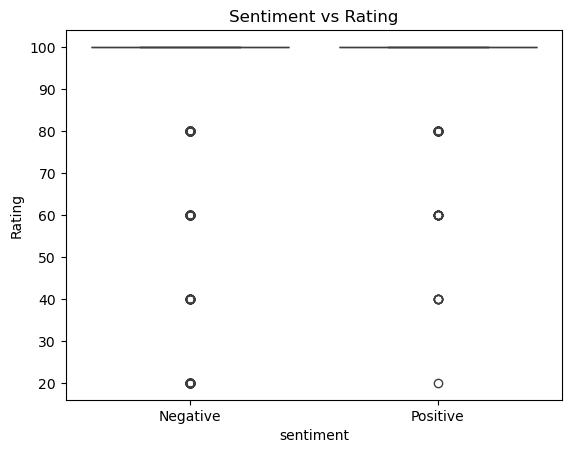

In [115]:

# Combined plot of Sentiment vs Rating
sns.boxplot(x='sentiment', y='Rating', data=df)
plt.title('Sentiment vs Rating')
plt.show()


In [116]:
df.tail(20)

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name,votes,is_no_review,polarity,sentiment
2172,4.000000e+12,100,14-Jan-24,No review,f***f,Israel,0,0,2024-01-14,2024,1,January,0,Customers with review,-0.000000,Negative
2173,4.000000e+12,100,19-Dec-23,No review,S***H,Canada,0,0,2023-12-19,2023,12,December,0,Customers with review,-0.000000,Negative
2174,4.000000e+12,100,06-Jan-24,No review,m***m,Greece,0,0,2024-01-06,2024,1,January,0,Customers with review,-0.000000,Negative
2175,4.000000e+12,100,29-Mar-24,No review,Amazon Shopper,Netherlands,0,0,2024-03-29,2024,3,March,0,Customers with review,-0.000000,Negative
2176,4.000000e+12,100,12-Feb-24,No review,Е***а,Russia,0,0,2024-02-12,2024,2,February,0,Customers with review,-0.000000,Negative
2177,4.000000e+12,100,14-Apr-24,No review,S***a,Belarus,0,0,2024-04-14,2024,4,April,0,Customers with review,-0.000000,Negative
2178,4.000000e+12,100,19-Dec-23,No review,S***H,Canada,0,0,2023-12-19,2023,12,December,0,Customers with review,-0.000000,Negative
2179,4.000000e+12,100,07-May-24,No review,Amazon Shopper,United Kingdom,0,0,2024-05-07,2024,5,May,0,Customers with review,-0.000000,Negative
2180,4.000000e+12,100,02-Apr-24,No review,y***l,France,0,0,2024-04-02,2024,4,April,0,Customers with review,-0.000000,Negative
2181,4.000000e+12,100,04-Apr-24,No review,s***s,Ukraine,0,0,2024-04-04,2024,4,April,0,Customers with review,-0.000000,Negative


In [117]:
df.head(5)

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name,votes,is_no_review,polarity,sentiment
0,1.010000e+15,100,18-May-24,Very good packaging well protected but not yet...,a***r,France,0,0,2024-05-18,2024,5,May,0,Customers with review,-0.9100,Negative
1,1.010000e+15,60,29-May-24,"lights are extremely bright, we used 1.2v batt...",Amazon Shopper,United States,0,0,2024-05-29,2024,5,May,0,Customers with review,-0.3375,Negative
2,1.010000e+15,100,25-May-24,I like it very much for my son. It is as the d...,R***S,Chile,0,0,2024-05-25,2024,5,May,0,Customers with review,0.2600,Positive
3,1.010000e+15,100,23-Apr-24,"corresponds to the description, fast delivery,...",Amazon Shopper,Ukraine,0,0,2024-04-23,2024,4,April,0,Customers with review,0.2000,Positive
4,1.010000e+15,100,03-May-24,As described. Good quality. Batteries not incl...,J***h,Hungary,0,0,2024-05-03,2024,5,May,0,Customers with review,-0.4500,Negative


## DATA PREPROCESSING
#### TEXT CLEANING

In [118]:
# cleaning the text using nltk
print (df['Feedback_translated'])

0       Very good packaging well protected but not yet...
1       lights are extremely bright, we used 1.2v batt...
2       I like it very much for my son. It is as the d...
3       corresponds to the description, fast delivery,...
4       As described. Good quality. Batteries not incl...
                              ...                        
2187                                            Very good
2188                                            No review
2189    looks fine, not tried yet!.......................
2190                                            No review
2191                                            No review
Name: Feedback_translated, Length: 2192, dtype: object


In [119]:
print (df['Feedback_translated'].iloc[7])

Great!! Fast!!


In [120]:
# converting to lower case
df['Feedback_translated'] = df['Feedback_translated'].str.lower()
# removing urls
df['Feedback_translated'] = df['Feedback_translated'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))
#removing punctuations
df['Feedback_translated'] = df['Feedback_translated'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
# removing numbers
df['Feedback_translated'] = df['Feedback_translated'].apply(lambda x: re.sub(r'\d+', '', x))
# removing extra space
df['Feedback_translated'] = df['Feedback_translated'].str.strip()
# removing special characters
df['Feedback_translated'] = df['Feedback_translated'].apply(lambda x: re.sub(r'[^A-Za-z\s]', '', x))

In [121]:
print (df['Feedback_translated'].iloc[7])

great fast


#### TOKENISATION

In [122]:
# carryout tokenisation for feedback translated

nltk.download("stopwords")
nltk.download ("punkt")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maryann/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/maryann/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [123]:
data_text=df['Feedback_translated'].iloc[25]

In [124]:
data_text

'i have not received the product'

In [125]:
# creating a function that will remove stop words
def remove_stopwords(text):
    stop_words= set(stopwords.words("english"))
    word_tokens=word_tokenize(text)
    cleaned_text=[word for word in word_tokens if word.lower()not in stop_words]
    return ' '.join(cleaned_text)

In [126]:
remove_stopwords(df['Feedback_translated'].iloc[112])

'arrive fast says description perfect'

In [127]:
tqdm.pandas()

In [128]:
df['cleaned_text']= df['Feedback_translated'].progress_apply(remove_stopwords)

100%|██████████| 2192/2192 [00:00<00:00, 12360.92it/s]


## FEATURE ENGINEERING
#### BAG OF WORDS VECTORS and TF-IDF

In [129]:
# converting text data into numerical feature vectors
df['cleaned_text'].iloc[1]

'lights extremely bright used v battery instead promoted v helped little top lights working'

In [130]:
Vectorizer_bow=CountVectorizer()

In [131]:
bow_matrix= Vectorizer_bow.fit_transform(df['cleaned_text'])

In [132]:
# transforming text data into TF-IDF matrices
vectorizer_tfidf=TfidfVectorizer()

In [133]:
tfidf_matrix=vectorizer_tfidf.fit_transform(df['cleaned_text'])

In [134]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12590 stored elements and shape (2192, 2659)>

## MODEL DEVELOPMENT
### A) CUSTOM MODELS
### 1. NAIVE BAYES

In [135]:
# Naive Bayes using bag of words (BOW)
x_train_bow,x_test_bow,y_train,y_test=train_test_split(bow_matrix, df['sentiment'],test_size=0.2, random_state=42)

In [136]:
# Naive Bayes using TF-IDF
x_train_tfidf,x_test_tfidf,y_train,y_test=train_test_split(tfidf_matrix, df['sentiment'],test_size=0.2, random_state=42)

In [137]:
# Training model on bag of words
nb_bow= MultinomialNB()

nb_bow.fit(x_train_bow,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [138]:
# Training model on TF-IDF
nb_tfidf = MultinomialNB()

nb_tfidf.fit(x_train_tfidf,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [139]:
y_pred_bow = nb_bow.predict(x_test_bow)
y_pred_tfidf = nb_tfidf.predict(x_test_tfidf)

#### EVALUATING MODEL USING ACCURACY MATRICS AND F1-SCORE

In [140]:
# Evaluating model on bag of words
accuracy_bow = accuracy_score(y_test,y_pred_bow)

print('Accuracy BOW')
print(accuracy_bow)

print (classification_report(y_test,y_pred_bow))

Accuracy BOW
0.8747152619589977
              precision    recall  f1-score   support

    Negative       0.94      0.85      0.89       269
    Positive       0.79      0.91      0.85       170

    accuracy                           0.87       439
   macro avg       0.87      0.88      0.87       439
weighted avg       0.88      0.87      0.88       439



##### Narration

In [141]:
# Evaluating model on TF-IDF
accuracy_tfidf = accuracy_score(y_test,y_pred_bow)

print('Accuracy TF-IDF')
print(accuracy_tfidf)

print (classification_report(y_test,y_pred_tfidf))

Accuracy TF-IDF
0.8747152619589977
              precision    recall  f1-score   support

    Negative       0.96      0.81      0.88       269
    Positive       0.76      0.95      0.85       170

    accuracy                           0.87       439
   macro avg       0.86      0.88      0.86       439
weighted avg       0.89      0.87      0.87       439



##### Narration

### 2. LOGISTIC REGRESSION (TRAINING AND EVALUATION)

In [142]:
# Training Logistic Regression with Bag of Words
lr_bow = LogisticRegression()
lr_bow.fit(x_train_bow, y_train)

y_pred_bow = lr_bow.predict(x_test_bow)

# Evaluate using accuracy and F1 score
accuracy_bow = accuracy_score(y_test, y_pred_bow)

print("Logistic Regression with Bag of Words")
print(accuracy_bow)

print(classification_report(y_test, y_pred_bow))

Logistic Regression with Bag of Words
0.8838268792710706
              precision    recall  f1-score   support

    Negative       0.95      0.86      0.90       269
    Positive       0.81      0.92      0.86       170

    accuracy                           0.88       439
   macro avg       0.88      0.89      0.88       439
weighted avg       0.89      0.88      0.88       439



<function matplotlib.pyplot.show(close=None, block=None)>

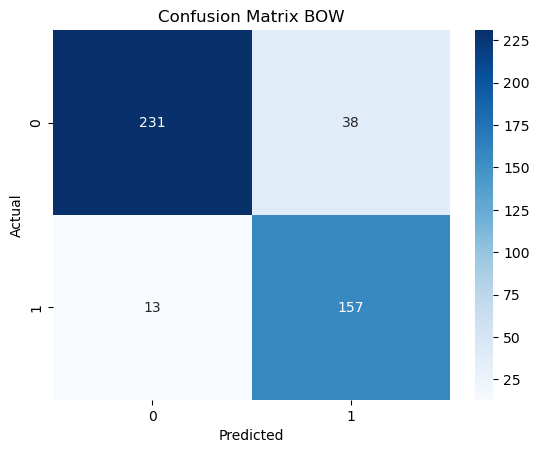

In [143]:
#Creating Confusion Matrix

lcm_bow=confusion_matrix(y_test,y_pred_bow)

#visualizing the confusion matrix

sns.heatmap(lcm_bow, annot=True, cmap="Blues", fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix BOW")
plt.show

In [144]:
# Training Logistic Regression with TF-IDF
lr_tfidf = LogisticRegression()
lr_tfidf.fit(x_train_tfidf, y_train)

y_pred_tfidf = lr_tfidf.predict(x_test_bow)

# Evaluate using accuracy and F1 score
accuracy_tfidf = accuracy_score(y_test, y_pred_bow)

print("Logistic Regression with TF-IDF")
print(accuracy_tfidf)

print(classification_report(y_test, y_pred_tfidf))

Logistic Regression with TF-IDF
0.8838268792710706
              precision    recall  f1-score   support

    Negative       0.97      0.78      0.86       269
    Positive       0.73      0.96      0.83       170

    accuracy                           0.85       439
   macro avg       0.85      0.87      0.85       439
weighted avg       0.88      0.85      0.85       439



<function matplotlib.pyplot.show(close=None, block=None)>

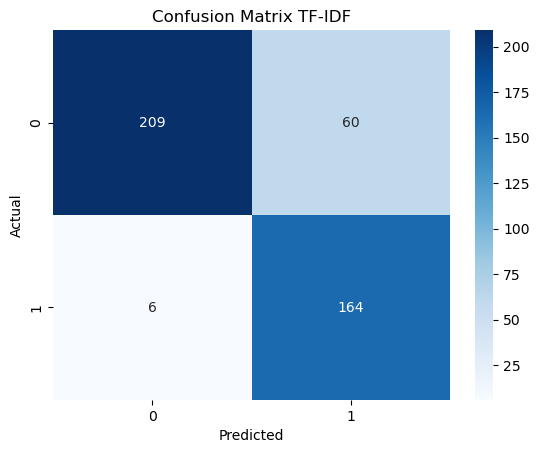

In [145]:
#Creating Confusion Matrix

lcm_tfidf=confusion_matrix(y_test,y_pred_tfidf)

#visualizing the confusion matrix

sns.heatmap(lcm_tfidf, annot=True, cmap="Blues", fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix TF-IDF")
plt.show

### 3. SUPPORT VECTOR MACHINE (SVM)

In [146]:
# Training SVM with Bag of Words
svm_bow = SVC()
svm_bow.fit(x_train_bow, y_train)

y_pred_bow = svm_bow.predict(x_test_bow)

# Evaluate using accuracy and F1 score
accuracy_bow = accuracy_score(y_test, y_pred_bow)

print("SVM with Bag of Words")
print(accuracy_bow)

print(classification_report(y_test, y_pred_bow))

SVM with Bag of Words
0.8701594533029613
              precision    recall  f1-score   support

    Negative       0.98      0.81      0.88       269
    Positive       0.76      0.97      0.85       170

    accuracy                           0.87       439
   macro avg       0.87      0.89      0.87       439
weighted avg       0.89      0.87      0.87       439



In [147]:
# Training SVM with TF-IDF
svm_tfidf = SVC()
svm_tfidf.fit(x_train_tfidf, y_train)

y_pred_tfidf = svm_tfidf.predict(x_test_tfidf)

# Evaluate using accuracy and F1 score
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("SVM with TF-IDF")
print(accuracy_tfidf)

print(classification_report(y_test, y_pred_tfidf))

SVM with TF-IDF
0.8473804100227791
              precision    recall  f1-score   support

    Negative       0.99      0.76      0.86       269
    Positive       0.72      0.98      0.83       170

    accuracy                           0.85       439
   macro avg       0.85      0.87      0.85       439
weighted avg       0.88      0.85      0.85       439



##### Narration

### B) PRE-TRAINED MODELS
### 1. VADER

In [148]:
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/maryann/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [149]:
analyzer= SentimentIntensityAnalyzer()


In [150]:


# Analyze the sentiment of the text
sentiment_scores = analyzer.polarity_scores('Feedback_translated')
# Output the sentiment scores
print(sentiment_scores)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [151]:
def generate_sentiment (text):
    scores = analyzer.polarity_scores (text)
    if scores['compound']>0:
        return 'Positive'
    #if scores['compound']< -0.5:
        #return 'Negative'
    else:
        return 'Negative'
    
print(f"The sentiment is: {sentiment}")

The sentiment is: 0       Positive
1       Positive
2       Positive
3       Positive
4       Positive
          ...   
2187    Positive
2188    Negative
2189    Positive
2190    Negative
2191    Negative
Name: Feedback_translated, Length: 2192, dtype: object


In [152]:
df['vader']= df['cleaned_text'].progress_apply(generate_sentiment)


100%|██████████| 2192/2192 [00:00<00:00, 21295.42it/s]


In [153]:
vectorizer_bow = CountVectorizer()

In [154]:
# creating bag of words
bow_df = vectorizer_bow.fit_transform(df['cleaned_text'])


In [155]:
# creating TF-IDF
tfidf_df = vectorizer_tfidf.fit_transform(df['cleaned_text'])

In [156]:
df['bow'] = nb_bow.predict(bow_df)

df['tfidf'] = nb_tfidf.predict(tfidf_df)

In [157]:
df.head(50)

,productId,Rating,Date,Feedback_translated,Name,Country,Upvotes,Downvotes,date_column,year,month,month_name,votes,is_no_review,polarity,sentiment,cleaned_text,vader,bow,tfidf
0,1.010000e+15,100,18-May-24,very good packaging well protected but not yet...,a***r,France,0,0,2024-05-18,2024,5,May,0,Customers with review,-0.910000,Negative,good packaging well protected yet mounted,Positive,Negative,Negative
1,1.010000e+15,60,29-May-24,lights are extremely bright we used v battery ...,Amazon Shopper,United States,0,0,2024-05-29,2024,5,May,0,Customers with review,-0.337500,Negative,lights extremely bright used v battery instead...,Positive,Negative,Negative
2,1.010000e+15,100,25-May-24,i like it very much for my son it is as the de...,R***S,Chile,0,0,2024-05-25,2024,5,May,0,Customers with review,0.260000,Positive,like much son description put batteries thank,Positive,Positive,Positive
3,1.010000e+15,100,23-Apr-24,corresponds to the description fast delivery w...,Amazon Shopper,Ukraine,0,0,2024-04-23,2024,4,April,0,Customers with review,0.200000,Positive,corresponds description fast delivery well pac...,Positive,Positive,Positive
4,1.010000e+15,100,03-May-24,as described good quality batteries not includ...,J***h,Hungary,0,0,2024-05-03,2024,5,May,0,Customers with review,-0.450000,Negative,described good quality batteries included fast...,Positive,Positive,Positive
5,1.010000e+15,100,14-May-24,works very well and is of good quality,D***v,Mexico,0,0,2024-05-14,2024,5,May,0,Customers with review,0.450000,Positive,works well good quality,Positive,Positive,Positive
6,1.010000e+15,100,23-May-24,excellent quality,Amazon Shopper,Hungary,0,0,2024-05-23,2024,5,May,0,Customers with review,1.000000,Positive,excellent quality,Positive,Positive,Positive
7,1.010000e+15,100,24-May-24,great fast,R***n,Israel,0,0,2024-05-24,2024,5,May,0,Customers with review,0.656250,Positive,great fast,Positive,Positive,Positive
8,1.010000e+15,100,17-May-24,excellent my baby loves it i recommend it to the,J***a,Spain,0,0,2024-05-17,2024,5,May,0,Customers with review,1.000000,Positive,excellent baby loves recommend,Positive,Positive,Positive
9,1.010000e+15,100,13-May-24,kid likes it a lot i like it even more because...,S***g,United Arab Emirates,0,0,2024-05-13,2024,5,May,0,Customers with review,-0.633333,Negative,kid likes lot like even annoying repeating aud...,Positive,Negative,Negative


#### EVALUATION

In [158]:
# scoring the model Vader
accuracy_vader = accuracy_score (df['sentiment'], df['vader'])

print('Accuracy Vader')
print (accuracy_vader)

print(classification_report(df['sentiment'], df['vader']))

Accuracy Vader
0.8822992700729927
              precision    recall  f1-score   support

    Negative       0.97      0.83      0.89      1304
    Positive       0.79      0.96      0.87       888

    accuracy                           0.88      2192
   macro avg       0.88      0.89      0.88      2192
weighted avg       0.90      0.88      0.88      2192



In [159]:
# scoring the model Bag of Words
accuracy_vader = accuracy_score (df['sentiment'], df['bow'])

print('Accuracy Bag of Words')
print (accuracy_vader)

print(classification_report(df['sentiment'], df['bow']))

Accuracy Bag of Words
0.9429744525547445
              precision    recall  f1-score   support

    Negative       0.99      0.92      0.95      1304
    Positive       0.89      0.98      0.93       888

    accuracy                           0.94      2192
   macro avg       0.94      0.95      0.94      2192
weighted avg       0.95      0.94      0.94      2192



In [160]:
# scoring the model TF-IDF
accuracy_vader = accuracy_score (df['sentiment'], df['tfidf'])

print('Accuracy TF-IDF')
print (accuracy_vader)

print(classification_report(df['sentiment'], df['tfidf']))

Accuracy TF-IDF
0.9251824817518248
              precision    recall  f1-score   support

    Negative       0.99      0.88      0.93      1304
    Positive       0.85      0.99      0.91       888

    accuracy                           0.93      2192
   macro avg       0.92      0.94      0.92      2192
weighted avg       0.93      0.93      0.93      2192



In [177]:
# Using Pre-trained models
# Textblob
from textblob import TextBlob

# Function to get sentiment from TextBlob
def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'pos'
    #elif analysis.sentiment.polarity < 0:
        #return 'neg'
    else:
        return 'neg'

# Apply TextBlob to the 'Feedback_translated' column
df['textblob_sentiment'] = df['Feedback_translated'].apply(get_textblob_sentiment)

# Print some results
print(df[['Feedback_translated', 'textblob_sentiment']].head())


                                 Feedback_translated textblob_sentiment
0  very good packaging well protected but not yet...                pos
1  lights are extremely bright we used v battery ...                pos
2  i like it very much for my son it is as the de...                pos
3  corresponds to the description fast delivery w...                pos
4  as described good quality batteries not includ...                pos


### HYPERPARAMETER OPTIMISATION 

In [162]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Ensure there are no NaNs in the 'Feedback_translated' column
df['Feedback_translated'] = df['Feedback_translated'].fillna('')

# Initialize vectorizer for Bag of Words (BoW)
vectorizer_bow = CountVectorizer()

# Create Bag of Words matrix
bow_df = vectorizer_bow.fit_transform(df['Feedback_translated'])

# Train-test split for validation
X_train_bow, X_test_bow, y_train, y_test = train_test_split(bow_df, df['sentiment'], test_size=0.3, random_state=42)

# Define hyperparameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],       # Regularization strength
    'solver': ['liblinear', 'lbfgs'],    # Solvers for Logistic Regression
    'max_iter': [100, 500, 1000]         # Maximum iterations
}

# Initialize Logistic Regression model
logreg = LogisticRegression()

# Use GridSearchCV to find the best parameters for Bag of Words
grid_search_bow = GridSearchCV(logreg, param_grid, cv=5, verbose=1)
grid_search_bow.fit(X_train_bow, y_train)

# Print best parameters for BoW model
print("Best parameters for BoW model:", grid_search_bow.best_params_)

# Evaluate best model for BoW on test data
bow_test_predictions = grid_search_bow.predict(X_test_bow)
print("BoW Accuracy:", accuracy_score(y_test, bow_test_predictions))
print("BoW Classification Report:\n", classification_report(y_test, bow_test_predictions))



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters for BoW model: {'C': 10, 'max_iter': 100, 'solver': 'liblinear'}
BoW Accuracy: 0.9544072948328267
BoW Classification Report:
               precision    recall  f1-score   support

    Negative       0.97      0.95      0.96       400
    Positive       0.93      0.96      0.94       258

    accuracy                           0.95       658
   macro avg       0.95      0.96      0.95       658
weighted avg       0.96      0.95      0.95       658



### BUILDING PIPELINES

In [163]:
# pipeline for naive bayes and count vectorizer
def get_sentiment(Feedback_translated):
    
    blob = TextBlob(Feedback_translated)
    polarity = blob.sentiment.polarity
    
    
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'
    
sentiment =df['Feedback_translated'].apply(get_sentiment)

def clean_text(text):
    text = text.lower()  
    text = re.sub(f"[{string.punctuation}]", "", text)  
    tokens = text.split()  
    stop_words = set(stopwords.words('english')) 
    tokens = [word for word in tokens if word not in stop_words]  
    return " ".join(tokens)

# Apply text cleaning BEFORE vectorizing
df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)

# Split the data
X = df['cleaned_review']  # Cleaned text should be used here
y = df['sentiment']  # Labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the pipeline with feature engineering (CountVectorizer), and model (Naive Bayes)
df_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Feature extraction
    ('classifier', MultinomialNB())  # Naive Bayes classifier
])

# Train the model
df_pipeline.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [164]:
# Evaluate the model
y_pred = df_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8861047835990888


In [165]:
# pipeline with vectorizer and log reg

def get_sentiment(Feedback_translated):
    
    blob = TextBlob(Feedback_translated)
    polarity = blob.sentiment.polarity
    
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'
    
sentiment =df['Feedback_translated'].apply(get_sentiment)

def clean_text(text):
    text = text.lower()  # Lowercase the text
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))  # Get stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return " ".join(tokens)


df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)


X = df['cleaned_review']  # Cleaned text should be used here
y = df['sentiment']  # Labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  
    ('classifier', LogisticRegression())  
])


pipeline.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [166]:
# Evaluate the model
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8861047835990888


In [167]:
# pipeline with vectorizer and SVM

def get_sentiment(Feedback_translated):
    
    blob = TextBlob(Feedback_translated)
    polarity = blob.sentiment.polarity
    
   
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'
    
sentiment =df['Feedback_translated'].apply(get_sentiment)

def clean_text(text):
    text = text.lower()  
    text = re.sub(f"[{string.punctuation}]", "", text)  
    tokens = text.split()  
    stop_words = set(stopwords.words('english'))  
    tokens = [word for word in tokens if word not in stop_words]  
    return " ".join(tokens)


df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)

# Split the data
X = df['cleaned_review']  
y = df['sentiment']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


df_pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),  # Feature extraction
    ('classifier', SVC())  
])

df_pipeline.fit(X_train, y_train)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [168]:
# Evaluate the model
y_pred = df_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8747152619589977


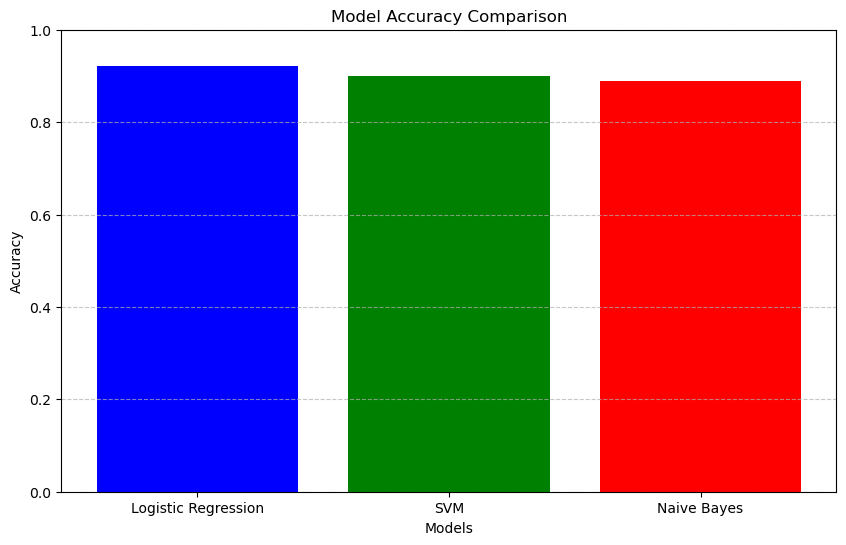

In [169]:
# Model names
models = ['Logistic Regression', 'SVM', 'Naive Bayes']

# Accuracy scores
accuracies = [0.9225, 0.8997,0.8883]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()

### SAVING THE TRAINED PIPELINE AS FILE

In [170]:
with open('sentiment_pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

### DEPLOYING THE MODEL

# using streamlit
        
with open('sentiment_pipeline.pkl', 'rb') as file:
    pipeline = pickle.load(file)

# Streamlit App
st.title("Sentiment Analysis App")

# Input for review text
review = st.text_area("Enter a review:")

if st.button("Analyze Sentiment"):
    if review:
        # Predict sentiment
        sentiment_prediction = pipeline.predict([review])
        
        # Display sentiment result
        st.write(f"Predicted Sentiment: {sentiment_prediction[0]}")
    else:
        st.write("Please enter a review to analyze.")

In [171]:
# using flask
# backend

In [172]:
# front end

#### piplelines with scaled 'rating' column

# NAIVE BAYES AND BOW
# Define the cleaning and sentiment functions
#def clean_text(text):
    text = text.lower()  # Lowercase the text
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))  # Get stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return " ".join(tokens)

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


# Apply text cleaning and sentiment classification
df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)
df['sentiment'] = df['Feedback_translated'].apply(get_sentiment)

# Define features and labels
X_text = df[['cleaned_review']]
X_ratings = df[['Rating']]
y = df['sentiment']

# Split the data
X_text_train, X_text_test, X_ratings_train, X_ratings_test, y_train, y_test = train_test_split(
    X_text, X_ratings, y, test_size=0.2, random_state=42
)

# Create pipelines for text and numerical data
text_pipeline = Pipeline([
    ('vectorizer', CountVectorizer())  # Feature extraction
])

rating_pipeline = Pipeline([
    ('scaler', MinMaxScaler())  # Scaling to [0, 1] range
])

# Combine text and numerical pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'cleaned_review'),
        ('Ratings', rating_pipeline, ['Rating'])  # Ensure rating is treated as a list
    ]
)

# Create the final pipeline with combined features and classifier
df_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MultinomialNB())  # Naive Bayes classifier
])

# Combine text and rating features for training
X_train_combined = pd.concat([X_text_train.reset_index(drop=True), X_ratings_train.reset_index(drop=True)], axis=1)
X_test_combined = pd.concat([X_text_test.reset_index(drop=True), X_ratings_test.reset_index(drop=True)], axis=1)

# Train the model
df_pipeline.fit(X_train_combined, y_train)



# Evaluate the model
print("Training score:", df_pipeline.score(X_test_combined, y_test))


# LOG REGRESSION AND BOW
# Define the cleaning and sentiment functions
def clean_text(text):
    text = text.lower()  # Lowercase the text
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))  # Get stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return " ".join(tokens)

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


# Apply text cleaning and sentiment classification
df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)
df['sentiment'] = df['Feedback_translated'].apply(get_sentiment)

# Define features and labels
X_text = df[['cleaned_review']]
X_ratings = df[['Rating']]
y = df['sentiment']

# Split the data
X_text_train, X_text_test, X_ratings_train, X_ratings_test, y_train, y_test = train_test_split(
    X_text, X_ratings, y, test_size=0.2, random_state=42
)

# Create pipelines for text and numerical data
text_pipeline = Pipeline([
    ('vectorizer', CountVectorizer())  # Feature extraction
])

rating_pipeline = Pipeline([
    ('scaler', MinMaxScaler())  # Scaling to [0, 1] range
])

# Combine text and numerical pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'cleaned_review'),
        ('Ratings', rating_pipeline, ['Rating'])  # Ensure rating is treated as a list
    ]
)

# Create the final pipeline with combined features and classifier
df_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression()) 
])

# Combine text and rating features for training
X_train_combined = pd.concat([X_text_train.reset_index(drop=True), X_ratings_train.reset_index(drop=True)], axis=1)
X_test_combined = pd.concat([X_text_test.reset_index(drop=True), X_ratings_test.reset_index(drop=True)], axis=1)

# Train the model
df_pipeline.fit(X_train_combined, y_train)


# Evaluate the model
print("Training score:", df_pipeline.score(X_test_combined, y_test))


In [173]:
# SVM AND BOW
# Define the cleaning and sentiment functions
def clean_text(text):
    text = text.lower()  # Lowercase the text
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))  # Get stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return " ".join(tokens)

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


# Apply text cleaning and sentiment classification
df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)
df['sentiment'] = df['Feedback_translated'].apply(get_sentiment)

# Define features and labels
X_text = df[['cleaned_review']]
X_ratings = df[['Rating']]
y = df['sentiment']

# Split the data
X_text_train, X_text_test, X_ratings_train, X_ratings_test, y_train, y_test = train_test_split(
    X_text, X_ratings, y, test_size=0.2, random_state=42
)

# Create pipelines for text and numerical data
text_pipeline = Pipeline([
    ('vectorizer', CountVectorizer())  # Feature extraction
])

rating_pipeline = Pipeline([
    ('scaler', MinMaxScaler())  # Scaling to [0, 1] range
])

# Combine text and numerical pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'cleaned_review'),
        ('Ratings', rating_pipeline, ['Rating'])  # Ensure rating is treated as a list
    ]
)

# Create the final pipeline with combined features and classifier
df_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC()) 
])

# Combine text and rating features for training
X_train_combined = pd.concat([X_text_train.reset_index(drop=True), X_ratings_train.reset_index(drop=True)], axis=1)
X_test_combined = pd.concat([X_text_test.reset_index(drop=True), X_ratings_test.reset_index(drop=True)], axis=1)

# Train the model
df_pipeline.fit(X_train_combined, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('Ratings', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Evaluate the model
print("Training score:", df_pipeline.score(X_test_combined, y_test))


# Model names
models = ['Logistic Regression', 'SVM', 'Naive Bayes']

# Accuracy scores
accuracies = [0.9362, 0.8792,0.9043]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()

# saving the trained pipeline as file
with open('sentiment_model.pkl', 'wb') as file:
    pickle.dump(df_pipeline, file)

# Deploying the model using streamlit

with open('sentiment_model.pkl', 'rb') as file:
    model = pickle.load(file)

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    tokens = text.split()
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Streamlit app
st.title("Sentiment Analysis App")

# User inputs
feedback = st.text_area("Enter your feedback:")
rating = st.number_input("Enter a rating (1 to 100):", min_value=1, max_value=100, step=1)

if st.button('Predict'):
    if feedback and rating:
        # Create a DataFrame from the input
        df = pd.DataFrame({'Feedback_translated': [feedback], 'Rating': [rating]})
        df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)
        
        # Prepare data for prediction
        X_text = df[['cleaned_review']]
        X_ratings = df[['Rating']]
        X_combined = pd.concat([X_text, X_ratings], axis=1)
        
        # Predict sentiment
        prediction = model.predict(X_combined)
        st.write(f"Sentiment: {prediction[0]}")
    else:
        st.write("Please provide both feedback and rating.")

# deploying the model using flask
# backend
from flask import Flask, request, jsonify
import pandas as pd
import re
import string
import pickle
from textblob import TextBlob
from nltk.corpus import stopwords

app = Flask(__name__)

# Load the model
with open('sentiment_model.pkl', 'rb') as file:
    model = pickle.load(file)

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    tokens = text.split()
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    feedback = data.get('Feedback_translated')
    rating = data.get('Rating')

    # Validate input
    if not feedback:
        return jsonify({'error': 'Feedback is required.'}), 400
    if rating is None or not (1 <= rating <= 100):
        return jsonify({'error': 'Rating must be between 1 and 100.'}), 400

    # Create a DataFrame from the input
    df = pd.DataFrame({'Feedback_translated': [feedback], 'Rating': [rating]})
    df['cleaned_review'] = df['Feedback_translated'].apply(clean_text)
    
    # Prepare data for prediction
    X_text = df[['cleaned_review']]
    X_ratings = df[['Rating']]
    X_combined = pd.concat([X_text, X_ratings], axis=1)
    
    # Predict sentiment
    prediction = model.predict(X_combined)
    return jsonify({'sentiment': prediction[0]})

if __name__ == '__main__':
    app.run(debug=True)


# flask
#front end (client)
import requests
import json

def predict_sentiment(feedback, rating):
    url = 'http://127.0.0.1:5000/predict'
    headers = {'Content-Type': 'application/json'}
    data = {
        'Feedback_translated': feedback,
        'Rating': rating
    }
    
    response = requests.post(url, headers=headers, data=json.dumps(data))
    
    if response.status_code == 200:
        result = response.json()
        return result['sentiment']
    else:
        error_message = response.json().get('error', 'Unknown error occurred.')
        return f"Error: {error_message}"

if __name__ == '__main__':
    # Example usage
    feedback = "This is a great product!"
    rating = 85
    sentiment = predict_sentiment(feedback, rating)
    print(f"Sentiment: {sentiment}")